In [1]:
# JupyterLab / VS Code에서는 %autosave 가 "IPython is not defined" JS 에러를 낸다.
# 클래식 노트북(nbclassic)에서만 아래를 해제하면 된다.
# %autosave 0
# print()은 값을 화면에 출력해 주는 함수로, 이 노트북이 실행 가능한 상태인지 확인하기 위해 쓰인다.
print("notebook ready")


notebook ready


# 4. Evaluation Metrics for Classification

In the previous session we trained a model for predicting churn. How do we know if it's good?


## 4.1 Evaluation metrics: session overview 

* Dataset: https://www.kaggle.com/blastchar/telco-customer-churn
* https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv


*Metric* - function that compares the predictions with the actual values and outputs a single number that tells how good the predictions are

In [2]:
# pandas는 표(테이블) 데이터를 다루는 라이브러리로, 고객 이탈 CSV를 DataFrame으로 다루기 위해 쓰인다.
import pandas as pd
# numpy는 숫자 배열 연산을 다루는 라이브러리로, 임계값 구간 생성과 행렬 계산을 위해 쓰인다.
import numpy as np

# matplotlib.pyplot은 그래프를 그리는 모듈로, 정확도·ROC 곡선을 시각화하기 위해 쓰인다.
import matplotlib.pyplot as plt


In [3]:
# train_test_split()은 데이터를 훈련/검증/테스트 비율로 나눠 주는 함수로,
# 모델이 보지 못한 데이터로 성능을 공정하게 평가하기 위해 쓰인다.
from sklearn.model_selection import train_test_split
# DictVectorizer는 딕셔너리 특성을 숫자 행렬로 바꿔 주는 변환기로,
# 범주형 변수를 원-핫 인코딩하기 위해 쓰인다.
from sklearn.feature_extraction import DictVectorizer
# LogisticRegression은 이진 분류용 로지스틱 회귀 모델로,
# 고객이 이탈할지 여부를 예측하기 위해 쓰인다.
from sklearn.linear_model import LogisticRegression

# set_config는 sklearn이 모델 객체를 화면에 어떻게 보여줄지 바꾸는 함수다.
from sklearn import set_config

# display="text": 모델 미리보기를 HTML이 아니라 글자로만 보여 준다.
# 한국어 Windows(cp949)에서 sklearn HTML 다이어그램이 깨지는 것을 막기 위해 필요하다.
# 데이터를 바꾸지는 않는다. 출력 방식만 바뀐다.
set_config(display="text")

# warnings는 파이썬 경고를 켜고 끄는 모듈이다.
import warnings
# ConvergenceWarning은 로지스틱 회귀가 반복 한도 안에 최적점을 못 찾았을 때 나는 경고다.
from sklearn.exceptions import ConvergenceWarning

# 레슨 코드는 LogisticRegression() 빈 괄호다. sklearn 1.9 기본은 solver='lbfgs', max_iter=100이다.
# 이 데이터(요금·계약기간 스케일이 다름)에서는 100회로 수렴하지 못해 경고가 난다.
# 강의 시절 기본 solver는 liblinear라 빈 괄호여도 경고가 거의 없었다.
# 경고만 숨긴다. fit은 끝나고 예측은 나온다. 평가 지표 학습에는 영향 없다.
warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [4]:
# read_csv()는 CSV 파일을 DataFrame으로 읽어 주는 함수로, 3주차와 같은 통신사 이탈 데이터를 불러오기 위해 쓰인다.
df = pd.read_csv('data-week-3.csv')

# columns는 컬럼 이름 목록이고, str.lower()/replace()는 문자열을 소문자로 바꾸고 공백을 _ 로 바꿔 주는 메서드로,
# 컬럼명을 다루기 쉽게 통일하기 위해 쓰인다.
df.columns = df.columns.str.lower().str.replace(' ', '_')

# select_dtypes()는 지정한 자료형 컬럼만 골라 주는 메서드이며,
# pandas 3 이상에서는 텍스트 데이터의 기본 타입이 string으로 변경되었기 때문에
# 기존 데이터(object)와 최신 string 타입을 모두 포함하여 텍스트형(범주형) 컬럼들을 누락 없이 안전하게 선택하기 위해 쓰인다.
categorical_columns = list(df.select_dtypes(include=['object', 'string']).columns)


# 범주형 컬럼마다 값을 소문자로 바꾸고 공백을 _ 로 정규화한다.
for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

# to_numeric()은 문자열을 숫자로 바꿔 주는 함수이자 totalcharges의 빈 칸을 숫자 결측으로 만들기 위해 쓰인다.
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
# fillna()는 결측값을 채워 주는 메서드로, 비어 있는 총요금을 0으로 두기 위해 쓰인다.
df.totalcharges = df.totalcharges.fillna(0)

# (df.churn == 'yes')는 이탈 여부를 True/False로 만들고 astype(int)는 1/0으로 바꿔 주는 메서드로,
# 분류 모델의 정답 레이블을 숫자로 만들기 위해 쓰인다.
df.churn = (df.churn == 'yes').astype(int)


In [5]:
# train_test_split()은 데이터를 비율대로 나눠 주는 함수로,
# 먼저 전체의 20%를 테스트셋으로 떼어 최종 평가용으로 쓰기 위해 쓰인다.
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
# 남은 80%를 다시 75:25로 나누면 전체 기준 60% 훈련 / 20% 검증이 된다.
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

# reset_index()는 행 번호를 0부터 다시 매겨 주는 메서드로, 나눈 뒤 인덱스를 깔끔하게 맞추기 위해 쓰인다.
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# .values는 컬럼을 NumPy 배열로 꺼내 주는 속성으로, 모델이 학습/평가할 정답(y)만 따로 두기 위해 쓰인다.
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

# del은 컬럼을 삭제하는 구문으로, 특성(X)에 정답이 섞이지 않게 churn을 빼기 위해 쓰인다.
del df_train['churn']
del df_val['churn']
del df_test['churn']


In [6]:
# 수치형 특성 목록. 가입 기간·월요금·총요금처럼 숫자 그대로 쓸 컬럼이다.
numerical = ['tenure', 'monthlycharges', 'totalcharges']

# 범주형 특성 목록. 성별·계약 종류 등 문자/코드 값이라 원-핫 인코딩이 필요한 컬럼이다.
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]


In [7]:
# DictVectorizer()은 파이썬 딕셔너리 형태의 데이터를 머신러닝 모델이 이해할 수 있는 수치 행렬로 변환해 주는 변환기로,
# sparse=False를 지정하여 결과를 희소 행렬이 아닌 밀집된 NumPy 2차원 배열로 반환받기 위해 쓰인다.
dv = DictVectorizer(sparse=False)

# to_dict()은 판다스 데이터프레임의 행들을 {컬럼명: 값} 형태의 딕셔너리 리스트로 변환해 주는 메서드로,
# 모델에 입력할 데이터를 딕셔너리 형태로 가공하기 위해 쓰인다.
train_dict = df_train[categorical + numerical].to_dict(orient='records')

# fit_transform()은 훈련 데이터의 카테고리별 고유 값을 학습하고 숫자로 변환해 주는 메서드로,
# 원-핫 인코딩을 수행하여 모델 학습용 피처 행렬(X_train)을 생성하기 위해 쓰인다.
X_train = dv.fit_transform(train_dict)

# LogisticRegression()은 이진 분류 문제를 풀기 위한 로지스틱 회귀 모델 인스턴스를 생성해 주는 함수로,
# 고객의 이탈 확률을 예측할 기준 모델을 준비하기 위해 쓰인다.
# 레슨 원본과 같이 빈 괄호를 쓴다. 기본 max_iter=100 수렴 경고는 위 import 셀에서 꺼 두었다.
model = LogisticRegression()

# fit()은 변환된 훈련 피처 데이터와 정답 레이블을 이용해 모델의 파라미터를 최적화하는 메서드로,
# 모델이 데이터를 보고 학습을 완료할 수 있도록 하기 위해 쓰인다.
model.fit(X_train, y_train)


LogisticRegression()

In [8]:
# to_dict()은 검증 데이터프레임의 범주형 및 수치형 컬럼 데이터를 딕셔너리 리스트로 변환해 주는 메서드로,
# 검증셋을 모델 입력용 포맷으로 맞추기 위해 쓰인다.
val_dict = df_val[categorical + numerical].to_dict(orient='records')

# transform()은 훈련 데이터에서 학습된 인코딩 규칙을 그대로 적용해 주는 메서드로,
# 데이터 유출을 방지하면서 원-핫 인코딩을 수행하여 검증 데이터의 피처 행렬(X_val)을 변환하기 위해 쓰인다.
X_val = dv.transform(val_dict)

# predict_proba()는 검증 데이터셋에 대한 클래스별 예측 확률을 2차원 배열로 계산해 주는 메서드로,
# 이 중 [:, 1] 슬라이싱을 통해 고객이 이탈(1)할 확률값만 추출하기 위해 쓰인다.
y_pred = model.predict_proba(X_val)[:, 1]

# (y_pred >= 0.5)는 모델이 예측한 각 고객의 이탈 확률값(y_pred, 0~1 사이의 소프트 예측)이 
# 기준 임계값인 0.5 이상인지 비교하여, 0.5 이상이면 이탈할 것으로 판단해 True(1), 
# 미만이면 잔류할 것으로 판단해 False(0) 값을 가지는 불리언 배열을 만들어 
# 최종 이탈 여부를 결정하는 하드 예측(churn_decision)을 수행하기 위해 쓰인다.
churn_decision = (y_pred >= 0.5)

# mean()은 불리언 배열의 평균을 계산해 주는 메서드로,
# 실제 정답(y_val)과 모델의 예측값(churn_decision)이 일치하는 비율을 구해 정확도(Accuracy)를 확인하기 위해 쓰인다.
# (y_val == churn_decision)은 실제 고객의 이탈 여부 정답(y_val)과 
# 모델이 임계값(0.5)을 기준으로 "이탈할 것이다(True/1)"라고 예측한 최종 이탈 예측 결정(churn_decision)을 비교하여,
# 예측이 맞으면 True(1), 틀리면 False(0)로 이루어진 불리언 배열을 만드는 연산이고,
# .mean()은 파이썬에서 True는 1, False는 0으로 취급되는 특성을 이용해 
# 전체 고객 중 이탈 여부를 정확하게 맞춘 비율(정확도, Accuracy)을 계산하기 위해 쓰인다.
(y_val == churn_decision).mean()



np.float64(0.8026969481902059)

## 4.2 Accuracy and dummy model

* Evaluate the model on different thresholds
* Check the accuracy of dummy baselines

In [9]:
# len()은 원소 개수를 세어 주는 함수로, 검증셋에 고객이 몇 명인지 확인하기 위해 쓰인다.
len(y_val)


1409

In [10]:
# 정답과 예측이 같은 비율(정확도)을 다시 확인한다. 바로 위 셀과 같은 계산이다.
(y_val == churn_decision).mean()


np.float64(0.8026969481902059)

In [11]:
# (y_val == churn_decision)은 실제 정답(y_val)과 모델의 이탈 예측(churn_decision)이 일치하는지 비교하여 
# 맞으면 True, 틀리면 False로 이루어진 불리언 배열을 만들고,
# .sum()은 파이썬에서 True는 숫자 1, False는 숫자 0으로 취급되는 특성을 이용해 
# 정답을 맞힌 총 고객 수(예: 1132명)를 산출하기 위해 쓰인다.
(y_val == churn_decision).sum()

np.int64(1131)

In [14]:
# (실제 환경이나 라이브러리 버전에 따라 맞힌 개수가 1132가 아닌 1131개로 산출될 수도 있다.)
# 1132는 맞힌 건수, 1409는 검증셋 크기이다.
# 나눗셈으로 정확도를 직접 계산해, 라이브러리 결과와 같은지 보기 위해 쓰인다.
1132 / 1409


0.8034066713981547

In [15]:
# accuracy_score()는 정답과 예측이 일치한 비율을 구해 주는 함수로,
# 사이킷런으로 정확도를 계산하기 위해 쓰인다.
# 실제 정답 레이블(y_val)과 모델의 예측 레이블(y_pred >= 0.5)이 일치하는 비율을 안전하게 계산하기 위해 쓰인다.
from sklearn.metrics import accuracy_score


In [16]:
# accuracy_score()는 실제 레이블과 예측 레이블의 일치 비율을 구해 주는 함수로,
# 확률을 0.5 기준으로 자른 뒤 모델 정확도를 확인하기 위해 쓰인다.
# 나> 참고로 y_pred >= 0.5는 이전의 churn_decision임
accuracy_score(y_val, y_pred >= 0.5)


0.8026969481902059

In [17]:
# linspace()는 시작과 끝 사이를 균등한 숫자로 나눠 주는 함수로,
# 임계값 0부터 1까지 0.05 간격(21개)을 만들기 위해 쓰인다.
thresholds = np.linspace(0, 1, 21)

# 각 임계값에서의 정확도를 담을 빈 리스트.
scores = []

# 임계값을 바꿔 가며 정확도가 어떻게 변하는지 본다.
for t in thresholds:
    # y_pred >= t 는 확률을 그 임계값으로 0/1 예측으로 바꾼다.
    score = accuracy_score(y_val, y_pred >= t)
    # print()는 임계값과 정확도를 소수점 자리로 보여 주기 위해 쓰인다.
    print('%.2f %.3f' % (t, score))
    # append()는 리스트 끝에 값을 넣는 메서드로, 나중에 그래프를 그리기 위해 쓰인다.
    scores.append(score)


0.00 0.274
0.05 0.510
0.10 0.592
0.15 0.667
0.20 0.710
0.25 0.739
0.30 0.760
0.35 0.772
0.40 0.785
0.45 0.794
0.50 0.803
0.55 0.801
0.60 0.796
0.65 0.786
0.70 0.766
0.75 0.744
0.80 0.734
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


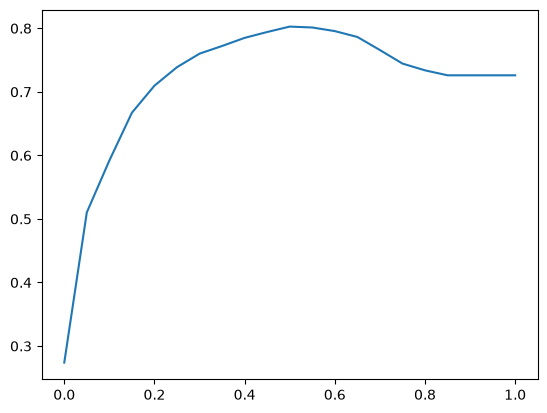

In [18]:
# plot()은 x-y 선 그래프를 그려 주는 함수로,
# 임계값에 따라 정확도가 어떻게 바뀌는지 보기 위해 쓰인다.
plt.plot(thresholds, scores)


In [19]:
# Counter는 값의 등장 횟수를 세어 주는 클래스로,
# True/False가 몇 개인지 세기 위해 쓰인다.
from collections import Counter


In [20]:
# y_pred >= 1.0 은 확률이 100% 이상이어야만 이탈로 판정하는 극단적인 조건식으로,
# 모든 예측을 강제로 False(잔류)로 만들어버리는 더미 모델의 작동 방식을 직관적으로 보여주기 위해 쓰인다.
# Counter()는 그 결과가 실제로 전부 False(아무도 이탈로 안 봄)로만 채워지는지 확인하기 위한 확인용 코드이다.
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [21]:
# y_val.mean()은 실제 이탈자(1)의 비율을 뜻하므로,
# 1에서 이 값을 빼면 이탈하지 않은 사람(0)들의 비율(약 72.6%)이 계산된다.
# 이는 "모두 잔류한다고 단순하게 예측했을 때(0)" 얻게 되는 정확도(더미의 정확도/베이스라인 기준선)가 된다.
1 - y_val.mean()

np.float64(0.7260468417317246)

## 4.3 Confusion table

* Different types of errors and correct decisions
* Arranging them in a table

In [22]:
# y_val == 1 은 실제로 이탈한 고객(양성)을 True로 표시하는 불리언 마스크이다.
actual_positive = (y_val == 1)
# y_val == 0 은 실제로 잔류한 고객(음성)을 True로 표시하는 불리언 마스크이다.
actual_negative = (y_val == 0)


In [23]:
# t는 이탈로 판정할 확률 기준(임계값)이다. 기본으로 0.5를 쓴다.
t = 0.5
# 모델이 이탈이라고 예측한 고객.
predict_positive = (y_pred >= t)
# 모델이 잔류라고 예측한 고객.
predict_negative = (y_pred < t)


In [24]:
# & 는 두 조건을 동시에 만족하는 원소만 True로 남기는 논리곱이다.
# sum()은 True 개수를 세어 주는 함수로, 혼동 행렬의 네 칸을 구하기 위해 쓰인다.
# tp: 실제 이탈 & 예측 이탈 (진양성)
tp = (predict_positive & actual_positive).sum()
# tn: 실제 잔류 & 예측 잔류 (진음성)
tn = (predict_negative & actual_negative).sum()

# fp: 실제 잔류인데 이탈로 예측 (위양성)
fp = (predict_positive & actual_negative).sum()
# fn: 실제 이탈인데 잔류로 예측 (위음성)
fn = (predict_negative & actual_positive).sum()


In [25]:
# np.array()는 파이썬 리스트를 NumPy 배열로 만들어 주는 함수로,
# 혼동 행렬을 [[TN, FP], [FN, TP]] 표로 보기 위해 쓰인다.
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
confusion_matrix


array([[921, 102],
       [176, 210]])

In [26]:
# sum()은 행렬 원소 합(전체 고객 수)을 구하고,
# 나눗셈은 각 칸의 비율, round(2)는 소수 둘째 자리로 반올림하기 위해 쓰인다.
(confusion_matrix / confusion_matrix.sum()).round(2)


array([[0.65, 0.07],
       [0.12, 0.15]])

## 4.4 Precision and Recall

In [27]:
# 정밀도(Precision) = TP / (TP + FP).
# "이탈이라고 예측한 사람 중 실제로 이탈한 비율"이다.
p = tp / (tp + fp)
p


np.float64(0.6730769230769231)

In [28]:
# 재현율(Recall) = TP / (TP + FN).
# "실제 이탈 고객 중 모델이 잡아낸 비율"이다.
r = tp / (tp + fn)
r


np.float64(0.5440414507772021)

## 4.5 ROC Curves

### TPR and FRP

In [29]:
# TPR(진짜 양성 비율)은 재현율과 같다. ROC 곡선의 세로축이다.
tpr = tp / (tp + fn)
tpr


np.float64(0.5440414507772021)

In [30]:
# FPR(거짓 양성 비율) = FP / (FP + TN).
# "실제 잔류 고객을 이탈로 잘못 본 비율"이며 ROC 곡선의 가로축이다.
fpr = fp / (fp + tn)
fpr


np.float64(0.09970674486803519)

In [31]:
# 임계값마다 TP/FP/FN/TN을 모아 둘 리스트.
scores = []

# 0부터 1까지 0.01 간격(101개) 임계값.
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    # 실제 양성/음성 마스크.
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    # 이 임계값에서의 예측 양성/음성.
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    # 혼동 행렬 네 칸을 센다.
    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    # append()로 (임계값, tp, fp, fn, tn) 튜플을 저장한다.
    scores.append((t, tp, fp, fn, tn))


In [32]:
# DataFrame()은 표로 만들어 주는 생성자로, 임계값별 혼동 행렬을 다루기 쉽게 하기 위해 쓰인다.
columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

# 각 임계값에서 TPR·FPR을 계산해 새 컬럼으로 넣는다.
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)


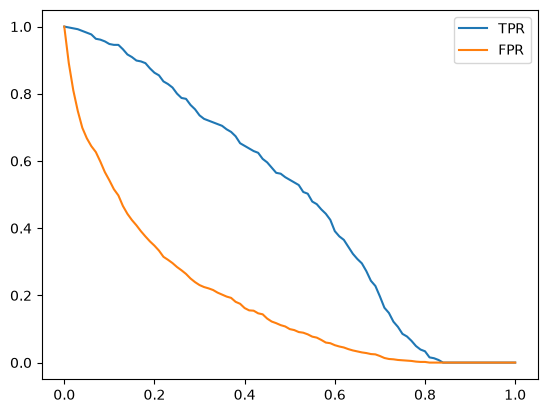

In [33]:
# 임계값(x)에 따라 TPR·FPR(y)이 어떻게 변하는지 그린다.
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')
# legend()는 선 이름 범례를 보여 주는 함수로, TPR/FPR을 구분하기 위해 쓰인다.
plt.legend()


### Random model

In [34]:
# seed()는 난수 순서를 고정해 주는 함수로, 다시 실행해도 같은 무작위 점수가 나오게 하기 위해 쓰인다.
np.random.seed(1)
# uniform()은 0~1 사이 난수를 만들어 주는 함수로,
# "아무 정보 없이 찍는" 무작위 모델의 예측 확률을 만들기 위해 쓰인다.
y_rand = np.random.uniform(0, 1, size=len(y_val))


In [36]:
# 무작위 확률을 0.5로 자른 예측이 실제와 맞는 비율(무작위 모델의 정확도)이다.
((y_rand >= 0.5) == y_val).mean()


np.float64(0.5017743080198722)

In [38]:
# tpr_fpr_dataframe()은 정답과 예측 확률을 받아 임계값별 TPR/FPR 표를 만들어 주는 함수로,
# 실제 모델·무작위·이상적 모델을 같은 방식으로 비교하기 위해 쓰인다.
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []

    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

    # return은 만든 표를 호출한 쪽으로 돌려 준다.
    return df_scores


In [39]:
# 무작위 예측(y_rand)에 대해 TPR/FPR 표를 만든다.
df_rand = tpr_fpr_dataframe(y_val, y_rand)


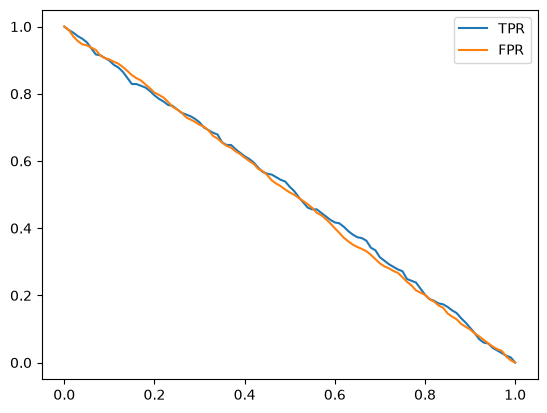

In [41]:
# 무작위 모델의 TPR/FPR이 임계값에 따라 어떻게 바뀌는지 그린다.
plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR')
plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR')
plt.legend()


In [25]:
# np.array()는 파이썬 리스트를 NumPy 배열로 만들어 주는 함수로,
# 혼동 행렬을 [[TN, FP], [FN, TP]] 표로 보기 위해 쓰인다.
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
confusion_matrix


array([[921, 102],
       [176, 210]])

### Ideal model

In [42]:
# sum()으로 검증셋에서 실제 잔류(0)·이탈(1) 고객 수를 센다.
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()
num_neg, num_pos


(np.int64(1023), np.int64(386))

In [43]:
# File name: 04-evaluation.ipynb
# (y_val == 0)과 (y_val == 1)은 각각 검증 정답 데이터에서 잔류 고객(0)과 이탈 고객(1)을 걸러내는 필터 역할을 하며,
# .sum()은 그 필터에 해당하는 고객의 총 개수(num_neg, num_pos)를 세어줍니다.
# np.repeat()은 앞서 구한 개수만큼 [0, 1] 값을 순서대로 반복하여, 
# 앞에는 음성(0)을 몰아넣고 뒤에는 양성(1)을 몰아넣은 완벽한 정렬 상태의 이상적 정답 배열을 만듭니다.
y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_ideal

# linspace()로 0부터 1까지 점점 커지는 점수를 만들어,
# 앞에 모인 음성은 낮은 점수, 뒤의 양성은 높은 점수를 갖게 한다(완벽한 모델).
y_ideal_pred = np.linspace(0, 1, len(y_val))

In [44]:
# 실제 데이터에서 비이탈 비율. 이상적 모델에서 음성과 양성을 가르는 임계값 힌트가 된다.
1 - y_val.mean()


np.float64(0.7260468417317246)

In [46]:
# 이상적 점수를 0.726(비이탈 비율)으로 자르면 정답을 완벽히 맞히므로 정확도는 1.0이 된다.
accuracy_score(y_ideal, y_ideal_pred >= 0.726)


1.0

In [47]:
# 이상적 모델의 임계값별 TPR/FPR 표.
# [::10]은 10행마다 하나씩 보는 슬라이싱으로, 표를 짧게 미리보기 위해 쓰인다.
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal[::10]


,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,386,882,0,141,1.000000,0.862170
20,0.2,386,741,0,282,1.000000,0.724340
30,0.3,386,600,0,423,1.000000,0.586510
40,0.4,386,459,0,564,1.000000,0.448680
50,0.5,386,319,0,704,1.000000,0.311828
60,0.6,386,178,0,845,1.000000,0.173998
70,0.7,386,37,0,986,1.000000,0.036168
80,0.8,282,0,104,1023,0.730570,0.000000
90,0.9,141,0,245,1023,0.365285,0.000000


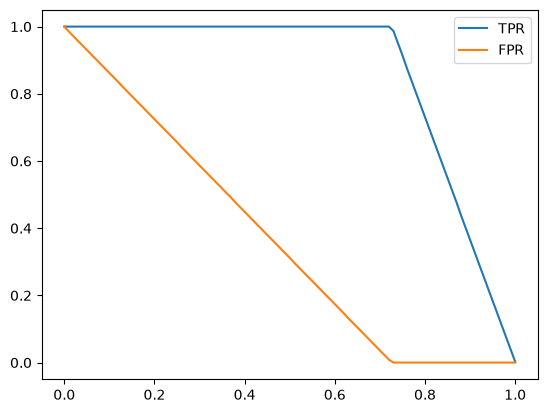

In [48]:
# 이상적 모델의 TPR/FPR 곡선.
plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR')
plt.legend()


### Putting everything together

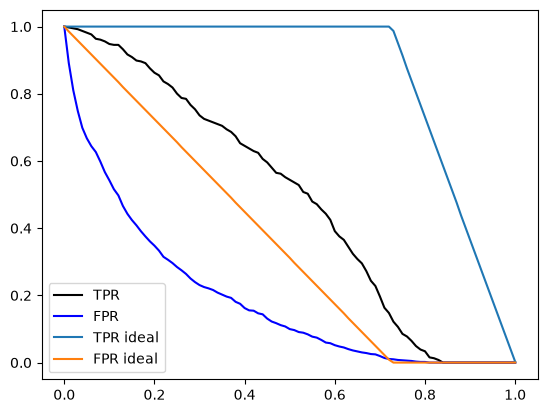

In [49]:
# 실제 모델(검정/파랑)과 이상적 모델의 TPR/FPR을 한 그림에 겹쳐 비교한다.
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR', color='black')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR', color='blue')

plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR ideal')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR ideal')

# 무작위 모델 곡선은 필요하면 주석을 해제한다.
# plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR random', color='grey')
# plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR random', color='grey')

plt.legend()


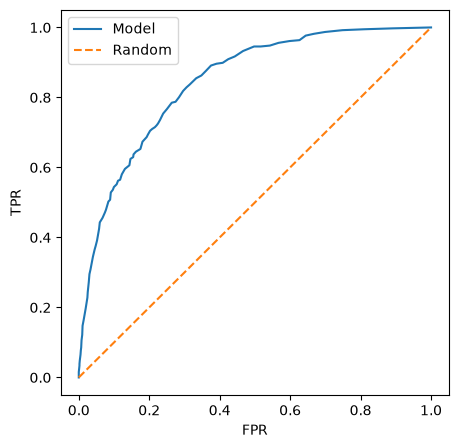

In [50]:
# figure()는 그림 크기를 정하는 함수로, ROC를 정사각형(5x5)으로 그리기 위해 쓰인다.
plt.figure(figsize=(5, 5))

# X축을 FPR(거짓 양성 비율, 오발령률), Y축을 TPR(진짜 양성 비율, 이탈자 포착률)로 설정하여 
# 모델의 성능을 시각화하는 ROC(Receiver Operating Characteristic) 곡선을 그린다.
# 곡선이 왼쪽 위 모서리(FPR=0, TPR=1)에 바짝 붙을수록 오발령은 적고 이탈자는 다 잡아내는 우수한 모델을 뜻한다.
plt.plot(df_scores.fpr, df_scores.tpr, label='Model')

# X축과 Y축이 모두 0에서 1까지 완벽하게 대칭을 이루는 대각선 점선([0, 1] 구간을 잇는 선)을 그린다.
# 이 대각선은 모델이 이탈 여부를 완전히 무작위(랜덤, 동전 던지기 수준)로 예측할 때 나타나는 기본 성능선이다.
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

# xlabel/ylabel은 축 이름을 붙이는 함수이다.
plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()


In [51]:
# roc_curve()는 정답과 예측 확률로 FPR, TPR, 임계값 배열을 계산해 주는 함수로,
# 사이킷런으로 ROC를 그리기 위해 쓰인다.
from sklearn.metrics import roc_curve


In [52]:
# 검증 정답(y_val)과 이탈 확률(y_pred)로 ROC용 FPR/TPR/임계값을 한 번에 구한다.
fpr, tpr, thresholds = roc_curve(y_val, y_pred)


In [ ]:
# 사이킷런이 계산한 FPR/TPR로 ROC 곡선을 다시 그린다.
plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()


## 4.6 ROC AUC

* Area under the ROC curve - useful metric
* Interpretation of AUC

In [53]:
# auc()는 곡선 아래 면적(Area Under Curve)을 구해 주는 함수로,
# ROC가 얼마나 좋은지 한 숫자로 요약하기 위해 쓰인다.
from sklearn.metrics import auc


In [54]:
# 사이킷런 ROC 점들로 AUC를 계산한다. 1에 가까울수록 좋다.
auc(fpr, tpr)


0.8438150517374987

In [55]:
# 우리가 직접 만든 df_scores의 FPR/TPR로도 AUC를 구해, 값이 비슷한지 확인한다.
auc(df_scores.fpr, df_scores.tpr)


0.843869498933848

In [56]:
# 이상적 모델의 AUC. 거의 1에 가깝다.
auc(df_ideal.fpr, df_ideal.tpr)


0.9999430203759136

In [57]:
# roc_curve + auc를 한 셀에서 이어서, 실제 모델 AUC를 다시 구한다.
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
auc(fpr, tpr)


0.8438150517374987

In [58]:
# roc_auc_score()는 ROC AUC를 한 번에 구해 주는 함수로,
# 곡선 점을 따로 만들지 않고 성능을 바로 보기 위해 쓰인다.
from sklearn.metrics import roc_auc_score


In [59]:
# 검증셋에서 모델의 ROC AUC.
roc_auc_score(y_val, y_pred)


0.8438150517374987

In [60]:
# 불리언 인덱싱: 실제 잔류(0) 고객의 예측 확률만 모은다.
neg = y_pred[y_val == 0]
# 실제 이탈(1) 고객의 예측 확률만 모은다.
pos = y_pred[y_val == 1]


In [61]:
# random은 난수 모듈로, AUC를 "무작위로 양성·음성을 뽑아 점수를 비교"하는 실험에 쓰기 위해 불러온다.
import random


In [62]:
# AUC의 의미: 무작위로 고른 이탈 고객의 점수가 잔류 고객보다 클 확률.
n = 100000
success = 0

for i in range(n):
    # randint()는 정수 난수를 뽑아 주는 함수로, 양성/음성 배열에서 한 명씩 고르기 위해 쓰인다.
    pos_ind = random.randint(0, len(pos) - 1)
    neg_ind = random.randint(0, len(neg) - 1)

    if pos[pos_ind] > neg[neg_ind]:
        success = success + 1

# 성공 비율이 ROC AUC와 비슷하게 나온다.
success / n


0.84496

In [63]:
# 파이썬 반복문 대신 NumPy로 같은 실험을 더 빠르게 한다.
n = 50000

np.random.seed(1)
# randint()에 size=n을 주면 인덱스 n개를 한 번에 뽑는다.
pos_ind = np.random.randint(0, len(pos), size=n)
neg_ind = np.random.randint(0, len(neg), size=n)

# 양성 점수가 음성보다 큰 비율 = AUC 추정값.
(pos[pos_ind] > neg[neg_ind]).mean()


np.float64(0.8464)

## 4.7 Cross-Validation

* Evaluating the same model on different subsets of data
* Getting the average prediction and the spread within predictions

In [64]:
# train()은 데이터프레임과 정답으로 벡터라이저+로지스틱 모델을 학습해 돌려 주는 함수로,
# 교차검증에서 같은 학습 절차를 반복하기 위해 묶어둠.
def train(df_train, y_train, C=1.0):
    # 특성을 딕셔너리 리스트로 바꾼다.
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    # C는 규제 강도(작을수록 규제가 큼). max_iter=1000은 레슨 원본과 같다.
    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model


In [65]:
# C=0.001처럼 규제가 강한 설정으로 한 번 학습해 본다.
dv, model = train(df_train, y_train, C=0.001)


In [66]:
# predict()는 이미 학습된 dv와 model로 이탈 확률만 계산해 주는 함수로,
# 검증/테스트셋에 같은 전처리를 적용하기 위해 쓰인다.
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    # transform만 사용한다(fit은 훈련셋에서 이미 끝남).
    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred


In [67]:
# 방금 학습한 모델로 검증셋 이탈 확률을 구한다.
y_pred = predict(df_val, dv, model)


In [68]:
# KFold는 데이터를 K개 폴드로 나눠 교차검증하는 도구로,
# 한 번 나눈 검증셋에만 의존하지 않고 성능을 더 안정적으로 추정하기 위해 쓰인다.
from sklearn.model_selection import KFold


In [69]:
# tqdm은 반복 작업의 진행 막대를 보여 주는 라이브러리로, C값 탐색이 얼마나 남았는지 보기 위해 쓰인다.
# 공용 ML .venv에 이미 설치되어 있고, 이 환경의 pip가 깨져 있어 !pip install 은 쓰지 않는다.
import tqdm
print("tqdm", tqdm.__version__)


tqdm 4.70.0


In [70]:
# tqdm.auto는 노트북에서 진행 막대가 잘 보이게 해 주는 import로,
# 교차검증 루프 진행률을 표시하기 위해 쓰인다.
from tqdm.auto import tqdm


E:\IT_SPACES\AI\ZoomCamp\ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [71]:
# 5-fold: 데이터를 5등분해 번갈아 검증한다.
n_splits = 5

# C(규제) 후보를 바꿔 가며, 각 C의 평균 AUC와 표준편차를 본다.
for C in tqdm([0.001, 0.01, 0.1, 0.5, 1, 5, 10]):
    # shuffle=True는 나누기 전 섞고, random_state=1은 재현 가능하게 한다.
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    # split()은 훈련/검증 행 번호(인덱스)를 넘겨 주는 메서드이다.
    for train_idx, val_idx in kfold.split(df_full_train):
        # iloc[]는 정수 위치로 행을 고르는 인덱서이다.
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    # mean/std는 폴드 AUC의 평균과 흩어짐을 보여 준다.
    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))


 14%|█▍        | 1/7 [00:03<00:23,  3.86s/it]

C=0.001 0.825 +- 0.009


 29%|██▊       | 2/7 [00:14<00:38,  7.69s/it]

C=0.01 0.840 +- 0.008


 43%|████▎     | 3/7 [00:22<00:32,  8.13s/it]

...

C=1 0.842 +- 0.007


 86%|████████▌ | 6/7 [00:46<00:07,  7.90s/it]

C=5 0.842 +- 0.007


100%|██████████| 7/7 [00:54<00:00,  7.72s/it]

C=10 0.842 +- 0.007


In [72]:
# 마지막 C에 대한 5개 폴드 AUC 리스트를 그대로 본다.
scores


[0.8445494579679883,
 0.8451426135611179,
 0.8333855107365041,
 0.8349887286563921,
 0.8516480499513663]

In [73]:
# 교차검증에서 고른 C=1.0으로, 훈련+검증을 합친 full_train 전체로 다시 학습한다.
dv, model = train(df_full_train, df_full_train.churn.values, C=1.0)
# 한 번도 학습에 안 쓴 테스트셋으로 최종 AUC를 구한다.
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc


0.8583327916626041

## 4.8 Summary

* Metric - a single number that describes the performance of a model
* Accuracy - fraction of correct answers; sometimes misleading 
* Precision and recall are less misleading when we have class inbalance
* ROC Curve - a way to evaluate the performance at all thresholds; okay to use with imbalance
* K-Fold CV - more reliable estimate for performance (mean + std)

## 4.9 Explore more

* Check the precision and recall of the dummy classifier that always predict "FALSE"
* F1 score = 2 * P * R / (P + R)
* Evaluate precision and recall at different thresholds, plot P vs R - this way you'll get the precision/recall curve (similar to ROC curve)
* Area under the PR curve is also a useful metric

Other projects:

* Calculate the metrics for datasets from the previous week